# Analisis Runtun Waktu Kualitas Udara (Sentinel-5P)
**Studi Kasus:** Kabupaten Bangkalan, Madura (Agustus 2025 - Agustus 2026)

## 1. Business Understanding
**Tujuan Proyek:**
Memetakan dan memantau secara proaktif fluktuasi kualitas udara di wilayah Kabupaten Bangkalan menggunakan data penginderaan jauh satelit Sentinel-5P selama kurun waktu satu tahun terakhir.

**Manfaat Proyek:**
1. **Sistem Peringatan Dini Kesehatan:** Memberikan peringatan berbasis data bagi masyarakat dan kelompok rentan saat angka polutan harian melonjak agar membatasi aktivitas *outdoor*.
2. **Evaluasi Tata Ruang & Kebijakan:** Menjadi landasan objektif bagi instansi terkait maupun pengelola kawasan (seperti Universitas Trunojoyo Madura) untuk mengevaluasi kepadatan lalu lintas dan efektivitas ruang terbuka hijau.
3. **Transparansi Informasi Publik:** Menerjemahkan matriks data satelit yang rumit menjadi grafik *time series* visual di portal web statis agar ancaman "polusi tak kasatmata" mudah dipahami oleh warga sipil.

---
## 2. Data Understanding
Dataset ini berisi rekaman harian konsentrasi gas polutan yang diekstrak menggunakan agregasi spasial (*Polygon GeoJSON*) wilayah Bangkalan.

**Deskripsi Fitur Polutan:**
* **CO (Karbon Monoksida):** *Silent killer* tak berbau dari pembakaran tidak sempurna, utamanya disumbang oleh asap knalpot kendaraan atau pembakaran sampah terbuka.
* **NO₂ (Nitrogen Dioksida):** Gas reaktif pemicu radang pernapasan, berasal dari emisi mesin bahan bakar fosil (terutama diesel) dan aktivitas industri.
* **O₃ (Ozon Permukaan):** Polutan sekunder berbahaya yang terbentuk dari reaksi kimia gas buang kendaraan di bawah terik matahari.
* **SO₂ (Sulfur Dioksida):** Gas berbau menyengat penyebab hujan asam, umumnya dari pembakaran batu bara atau emisi bahan bakar kapal laut di area pesisir.

**Catatan Eksplorasi Data (Anomali):**
Dalam data satelit optik, terdapat kondisi wajar yang perlu diperhatikan:
1. **Missing Values (NaN):** Terjadi ketika wilayah tertutup awan mendung/hujan, sehingga sensor satelit tidak dapat menembus permukaan bumi.
2. **Outliers (Pencilan):** Lonjakan nilai ekstrem pada hari tertentu yang bisa merekam insiden nyata (kebakaran lahan) atau sekadar *noise* instrumen.

---
## 3. Persiapan Lingkungan & Koneksi Server
Langkah teknis dimulai dengan memasang pustaka `openeo` dan mengautentikasi sistem lokal ke peladen Copernicus Data Space Ecosystem (CDSE). Koordinat Bangkalan didefinisikan menggunakan GeoJSON.

In [4]:
!pip install openeo
import openeo
import json
import pandas as pd
from functools import reduce
import time

print("Menghubungkan ke CDSE Copernicus...")
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.2/349.2 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 14.0 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0
Menghubungkan ke CDSE Copernicus...


Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=UJRM-LRZF 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


### Langkah Pertama kita klik link yang muncul untuk verifikasi


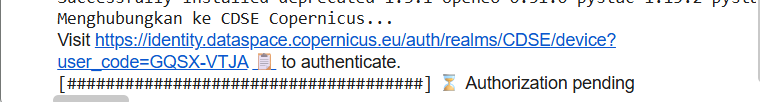

### Selanjutnya Login Account Dataspace Copernicus kita

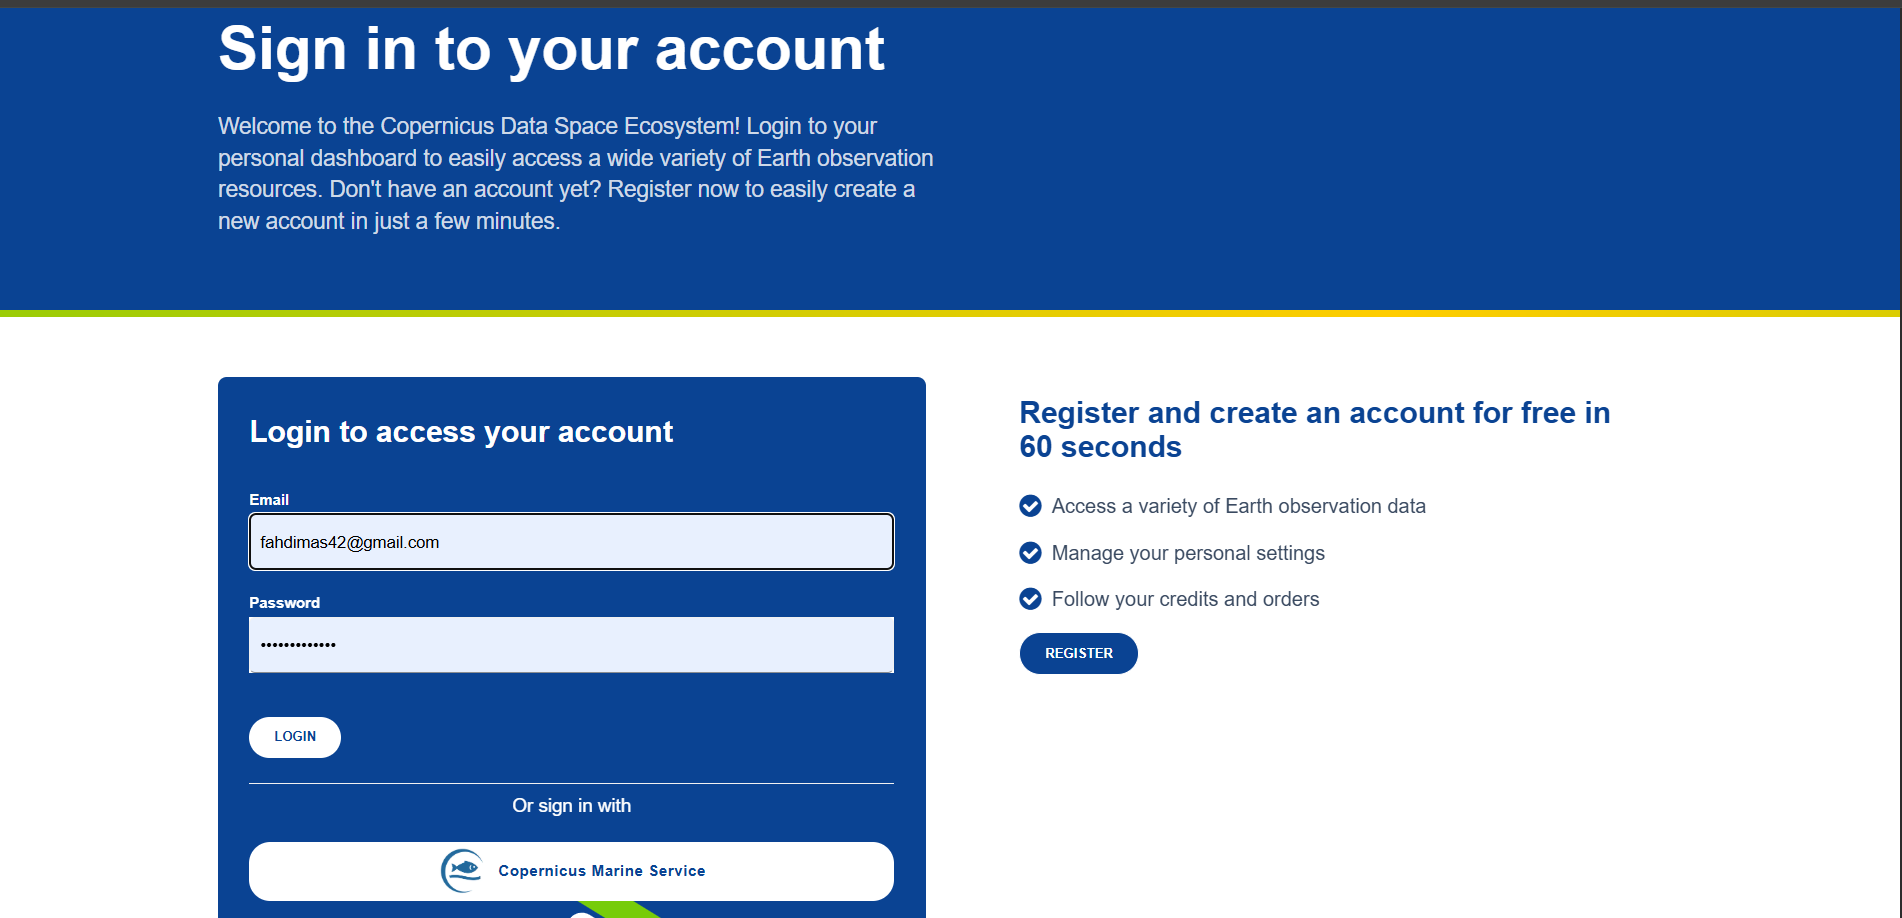

### Setelah kita Login Account kita maka akan muncul untuk mengecek apakah kita akan memberikan access atau tidak

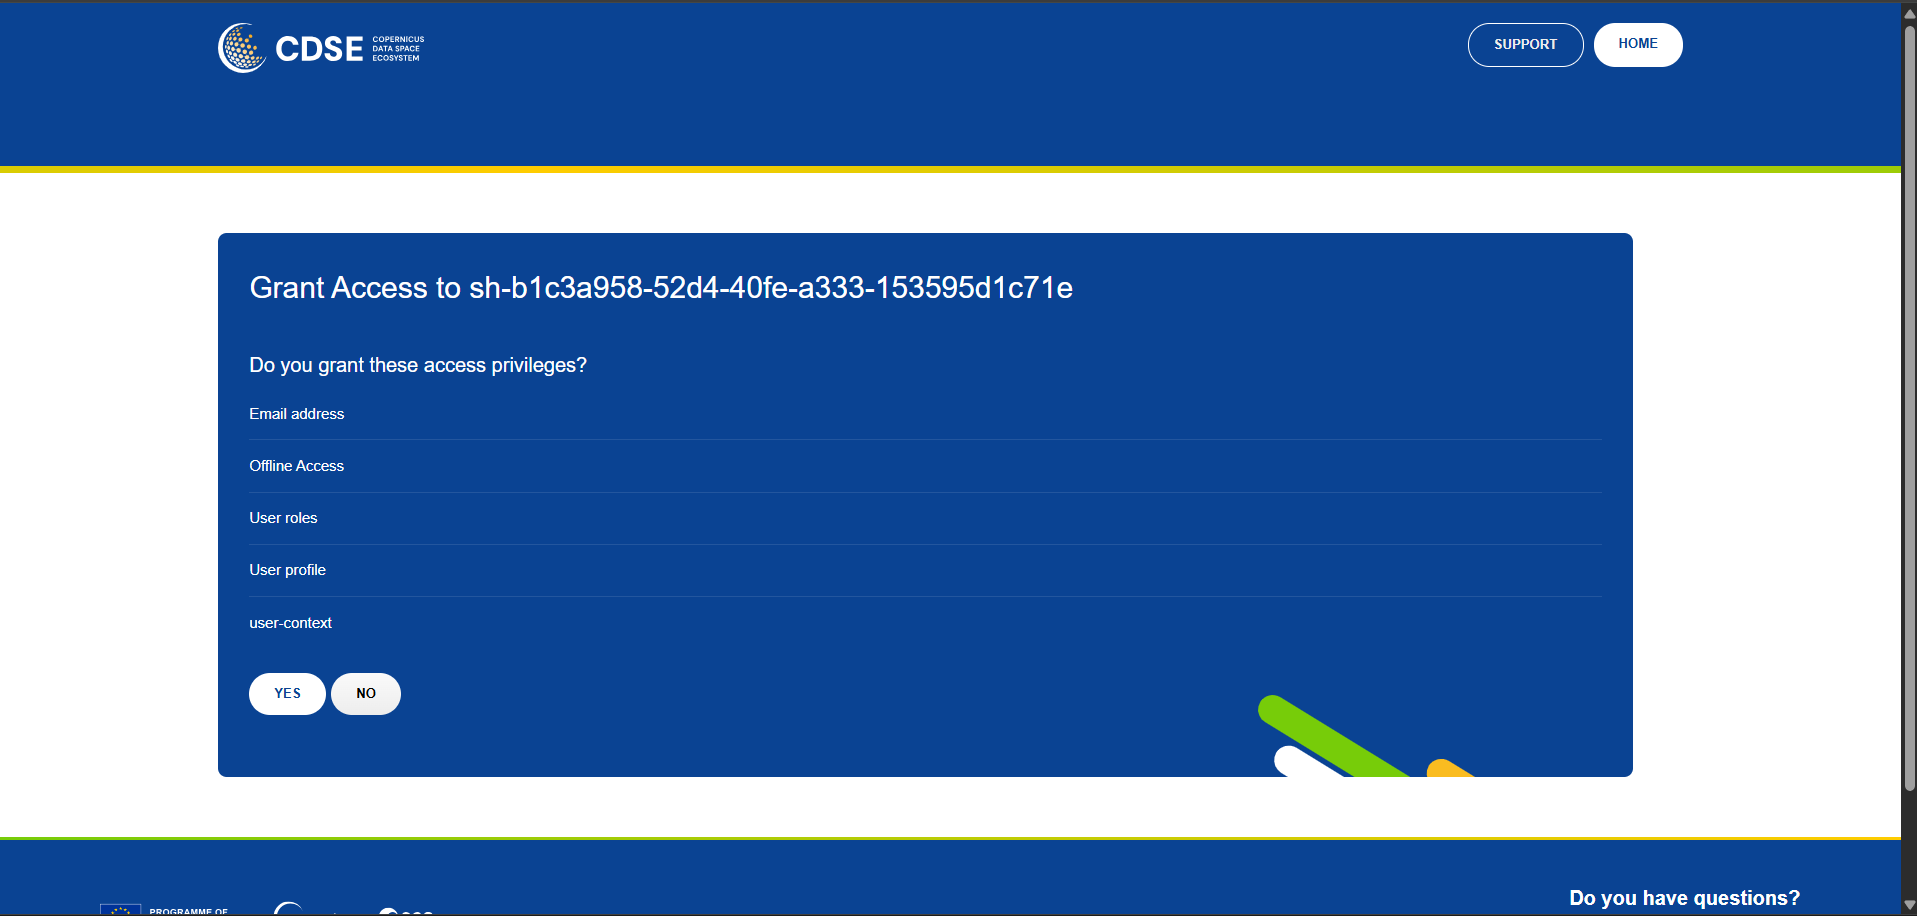

### setelah itu akan muncul tampilan Device Login Successful

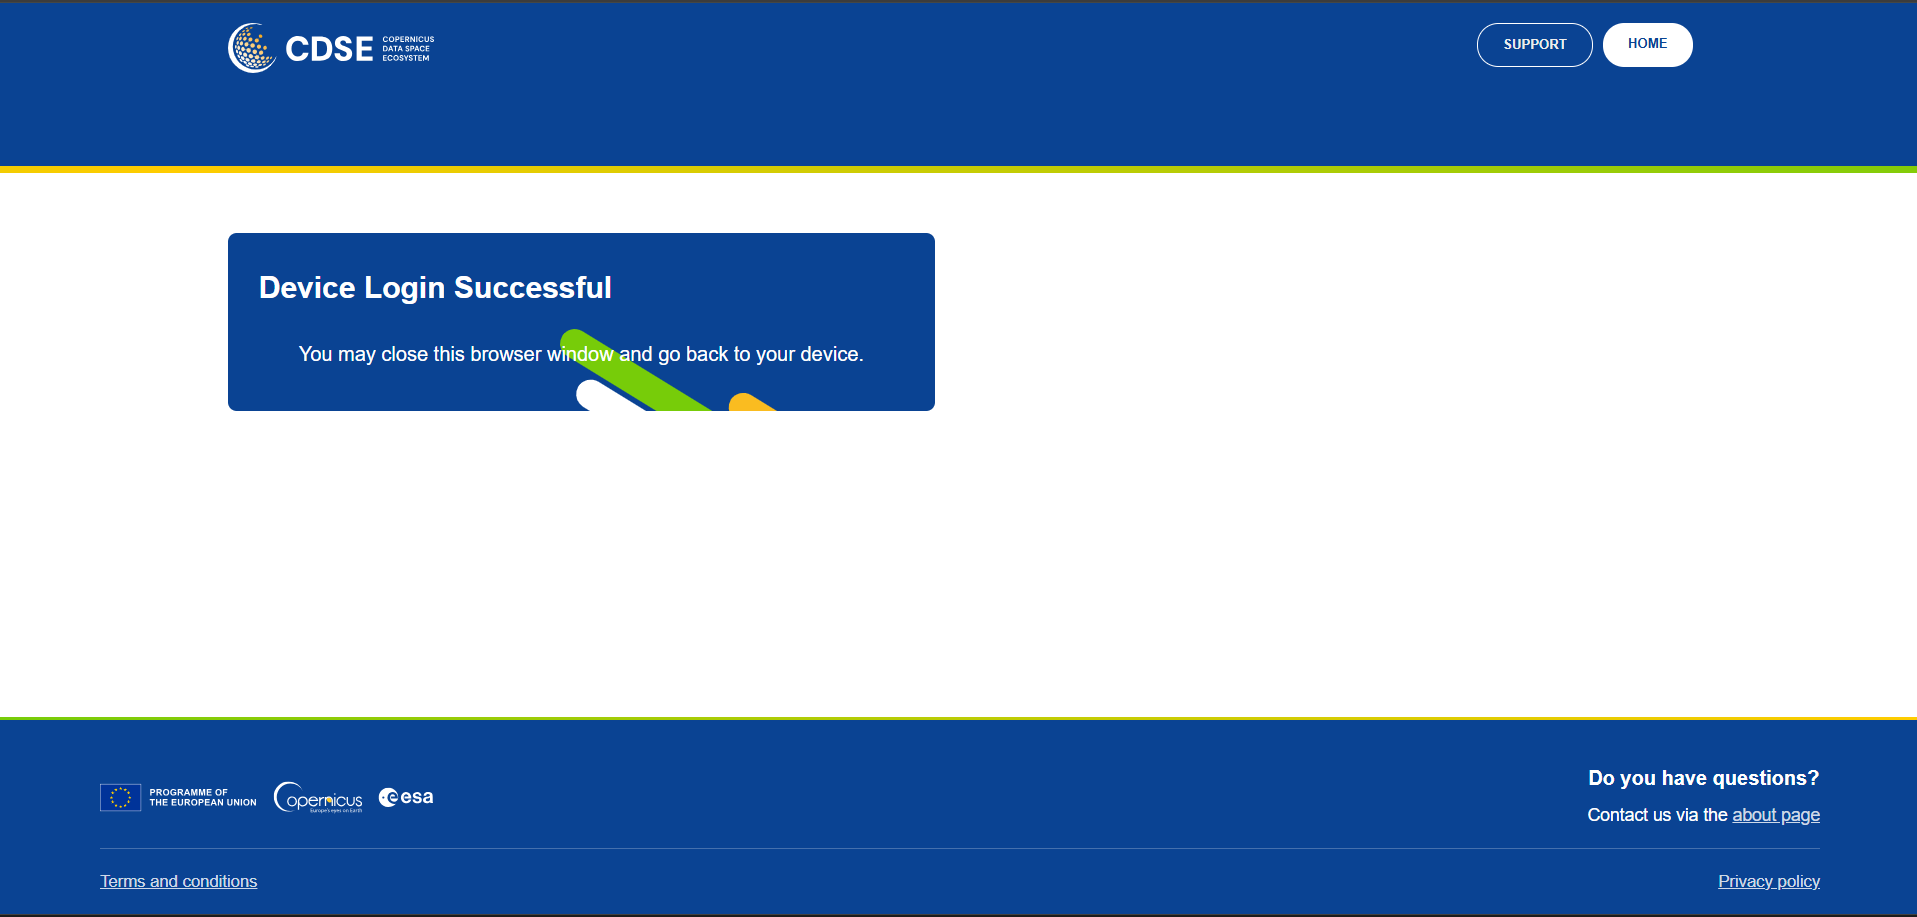

### Pengambilan Koordinat Bangkalan Menggunakan Website Geojson.io
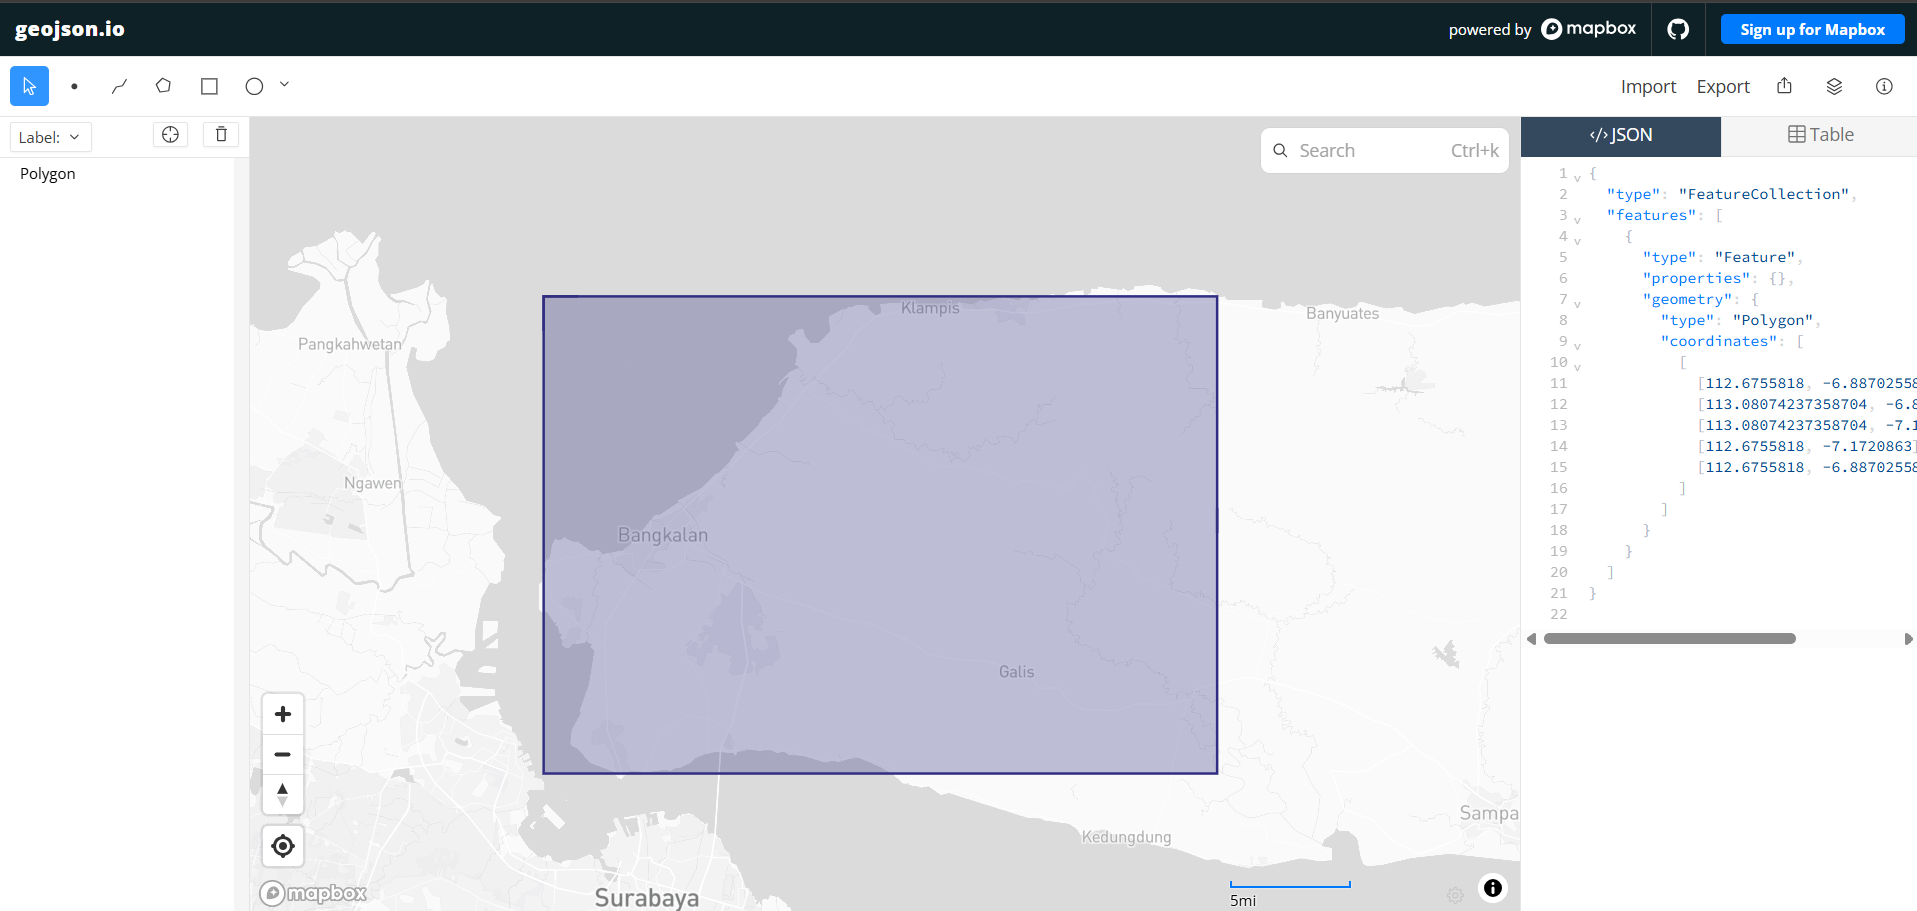

In [5]:
aoi = {
    "type": "Polygon",
    "coordinates": [
        [[112.6755818, -6.8870255898287525],
         [113.08074237358704, -6.8870255898287525],
         [113.08074237358704, -7.1720863],
         [112.6755818, -7.1720863],
         [112.6755818, -6.8870255898287525]]
    ]
}

---
## 4. Ekstraksi Data Satelit Otomatis (Batch Job)
Data diunduh secara bergiliran (*looping*) untuk mencegah *timeout* peladen. Setiap kubus data diagregasi secara spasial (seluruh grid Bangkalan menjadi 1 nilai rata-rata) dan temporal (rata-rata harian).

In [6]:
gases = ["NO2", "CO", "O3", "SO2"]

for gas in gases:
    print(f" Memproses ekstraksi gas {gas}...")

    cube = connection.load_collection(
        "SENTINEL_5P_L2",
        temporal_extent=["2025-08-01", "2026-08-25"],
        spatial_extent={"west": 112.6755818, "south": -7.1720863, "east": 113.08074237358704, "north": -6.8870255898287525},
        bands=[gas]
    )
    cube_aoi = cube.aggregate_temporal_period(reducer="mean", period="day").aggregate_spatial(reducer="mean", geometries=aoi)

    nc_filename = f"{gas}_Bangkalan.nc"
    job = cube_aoi.execute_batch(title=f"{gas}_Bangkalan")
    job.download_result(target=nc_filename)

    # Konversi JSON teks ke CSV
    with open(nc_filename, "r") as f:
        data_json = json.load(f)

    records = []
    for date_str, value_list in data_json.items():
        val = value_list[0][0] if value_list and value_list[0] else None
        records.append({'date': date_str, gas: val})

    df = pd.DataFrame(records)
    df['date'] = pd.to_datetime(df['date']).dt.date
    df = df.sort_values('date').reset_index(drop=True)

    csv_filename = f"{gas}_Bangkalan.csv"
    df.to_csv(csv_filename, index=False)
    print(f" Data {gas} diekspor menjadi {csv_filename}")

 Memproses ekstraksi gas NO2...
0:00:00 Job 'j-26083010381846f98ee4bb947f407b07': send 'start'
0:00:02 Job 'j-26083010381846f98ee4bb947f407b07': created (progress 0%)
0:00:08 Job 'j-26083010381846f98ee4bb947f407b07': queued (progress 0%)
0:00:14 Job 'j-26083010381846f98ee4bb947f407b07': queued (progress 0%)
0:00:22 Job 'j-26083010381846f98ee4bb947f407b07': queued (progress 0%)
0:00:32 Job 'j-26083010381846f98ee4bb947f407b07': queued (progress 0%)
0:00:45 Job 'j-26083010381846f98ee4bb947f407b07': queued (progress 0%)
0:01:01 Job 'j-26083010381846f98ee4bb947f407b07': running (progress N/A)
0:01:20 Job 'j-26083010381846f98ee4bb947f407b07': running (progress N/A)
0:01:44 Job 'j-26083010381846f98ee4bb947f407b07': running (progress N/A)
0:02:14 Job 'j-26083010381846f98ee4bb947f407b07': running (progress N/A)
0:02:52 Job 'j-26083010381846f98ee4bb947f407b07': running (progress N/A)
0:03:39 Job 'j-26083010381846f98ee4bb947f407b07': finished (progress 100%)
 Data NO2 diekspor menjadi NO2_Bangkal

---
## 5. Audit Kualitas Data (Missing Values)
Pengecekan jumlah data kosong akibat halangan awan sebelum proses penggabungan tabel.

In [7]:
print("Rekapitulasi Titik Data Kosong (Tutupan Awan):")
for gas in gases:
    df = pd.read_csv(f"{gas}_Bangkalan.csv")
    missing_values = df[gas].isna().sum()
    print(f" - {gas}: {missing_values} data kosong dari {len(df)} hari.")

Rekapitulasi Titik Data Kosong (Tutupan Awan):
 - NO2: 86 data kosong dari 390 hari.
 - CO: 97 data kosong dari 390 hari.
 - O3: 5 data kosong dari 390 hari.
 - SO2: 59 data kosong dari 390 hari.


---
## 6. Integrasi Dataset (Outer Join)
Menyatukan 4 tabel polutan ke dalam satu *Master Dataset* berdasarkan penanggalan, menjaga kelengkapan baris meski ada gas yang kosong pada hari tertentu.

In [8]:
files = [f"{gas}_Bangkalan.csv" for gas in gases]
dfs = [pd.read_csv(f) for f in files]

for df in dfs:
    df['date'] = pd.to_datetime(df['date'])

# Menggabungkan data
df_merged = reduce(lambda left, right: pd.merge(left, right, on='date', how='outer'), dfs)
df_merged = df_merged.sort_values('date').reset_index(drop=True)

output_file = "Polusi_Bangkalan_Merged.csv"
df_merged.to_csv(output_file, index=False)

print(f"✅ Master Dataset tersimpan: {output_file}")
df_merged.head()

✅ Master Dataset tersimpan: Polusi_Bangkalan_Merged.csv


,date,NO2,CO,O3,SO2
0,2025-07-31,NaN,NaN,NaN,NaN
1,2025-08-01,0.000012,0.026199,0.113517,-0.000021
2,2025-08-02,0.000019,0.025556,0.114225,0.000039
3,2025-08-03,0.000012,0.025859,0.114091,0.000002
4,2025-08-04,0.000026,0.029700,0.116046,0.000029


### Persiapan Visualisasi install matplotlib


In [9]:
!pip install matplotlib

---
## 4. Visualisasi Time Series (Hasil Akhir)
### 4.1 Fluktuasi Nitrogen Dioksida (NO₂)
Garis terputus mengindikasikan ketiadaan data akibat awan. Puncak lonjakan harian menunjukkan korelasi tingginya aktivitas kendaraan berbahan bakar fosil atau industri pada hari tertentu.

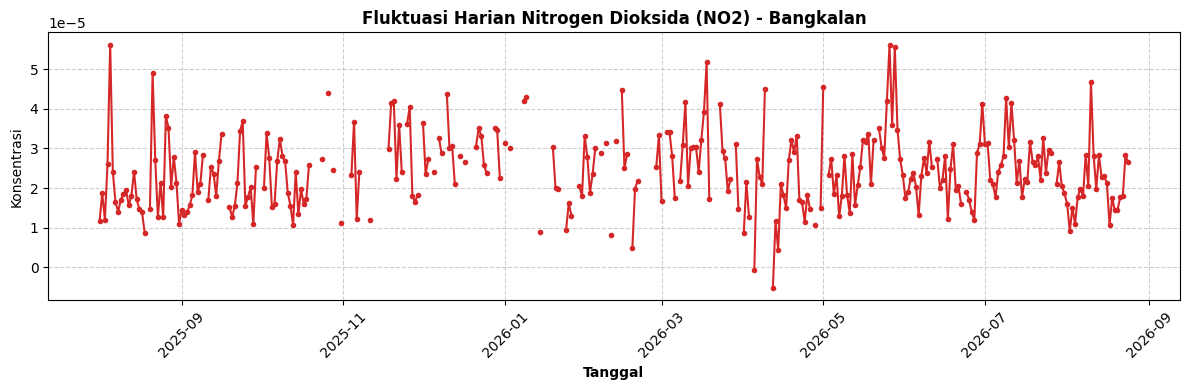

In [10]:
import matplotlib.pyplot as plt
df_merged['date'] = pd.to_datetime(df_merged['date'])

plt.figure(figsize=(12, 4))
plt.plot(df_merged['date'], df_merged['NO2'], color='tab:red', marker='o', markersize=3, linewidth=1.5)
plt.title('Fluktuasi Harian Nitrogen Dioksida (NO2) - Bangkalan', fontweight='bold')
plt.xlabel('Tanggal', fontweight='bold')
plt.ylabel('Konsentrasi')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.2 Fluktuasi Karbon Monoksida (CO)
Grafik umumnya memiliki *baseline* yang konstan karena emisi rutin kendaraan. Pencilan (*outlier*) ekstrem melambangkan kejadian lokal seperti pembakaran sampah massal atau kebakaran lahan.

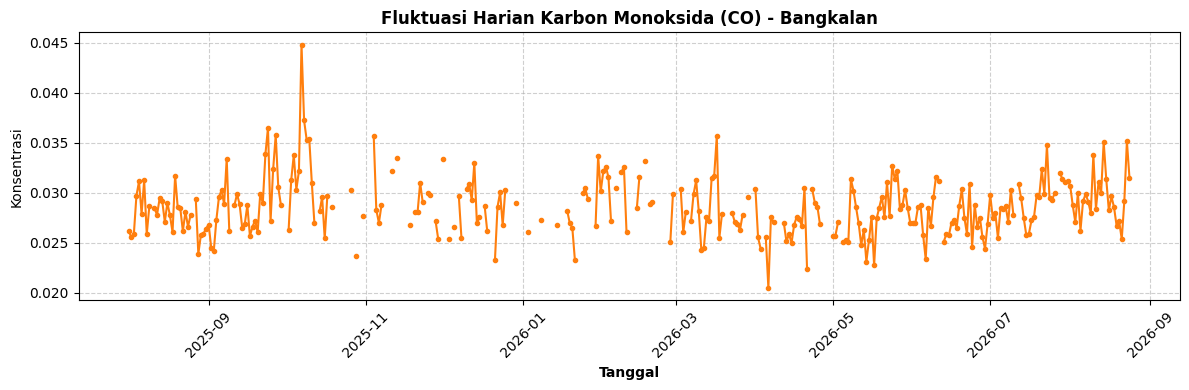

In [11]:
plt.figure(figsize=(12, 4))
plt.plot(df_merged['date'], df_merged['CO'], color='tab:orange', marker='o', markersize=3, linewidth=1.5)
plt.title('Fluktuasi Harian Karbon Monoksida (CO) - Bangkalan', fontweight='bold')
plt.xlabel('Tanggal', fontweight='bold')
plt.ylabel('Konsentrasi')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.3 Fluktuasi Ozon Permukaan (O₃)
Karena sangat dipengaruhi oleh cuaca, plot grafik ini akan menunjukkan dinamika yang sejalan dengan intensitas paparan sinar matahari di Madura.

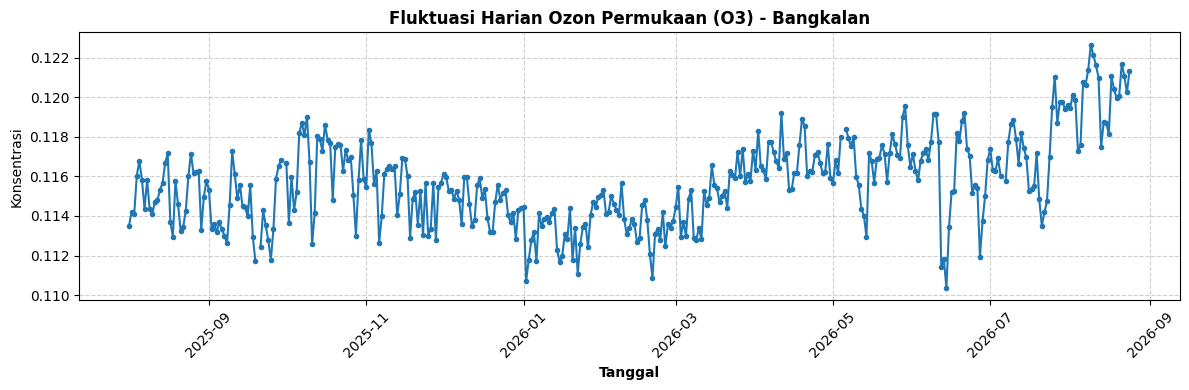

In [12]:
plt.figure(figsize=(12, 4))
plt.plot(df_merged['date'], df_merged['O3'], color='tab:blue', marker='o', markersize=3, linewidth=1.5)
plt.title('Fluktuasi Harian Ozon Permukaan (O3) - Bangkalan', fontweight='bold')
plt.xlabel('Tanggal', fontweight='bold')
plt.ylabel('Konsentrasi')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.4 Fluktuasi Sulfur Dioksida (SO₂)
Didominasi nilai mendekati nol. Lonjakan ke arah atas berkaitan dengan paparan emisi perkapalan di Selat Madura, sementara penurunan fluktuatif ke area negatif mencerminkan batas ambang bacaan instrumen satelit (*noise* tingkat kepastian rendah).

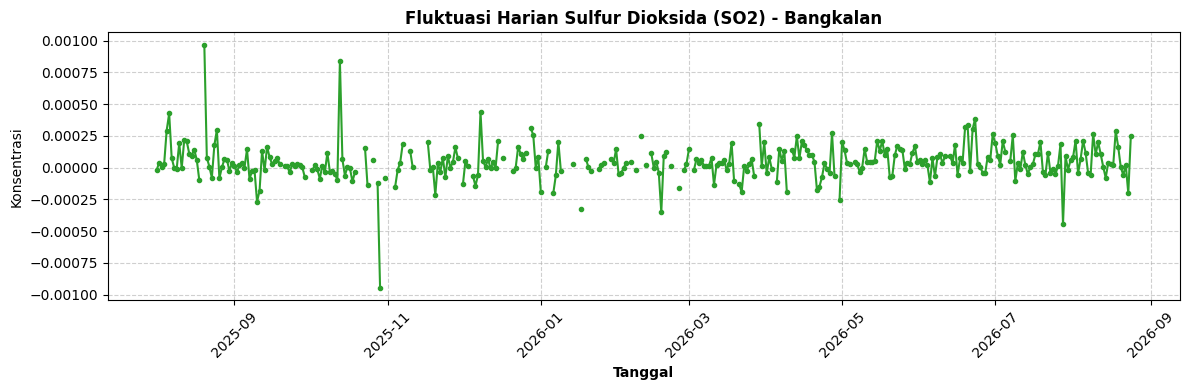

In [13]:
plt.figure(figsize=(12, 4))
plt.plot(df_merged['date'], df_merged['SO2'], color='tab:green', marker='o', markersize=3, linewidth=1.5)
plt.title('Fluktuasi Harian Sulfur Dioksida (SO2) - Bangkalan', fontweight='bold')
plt.xlabel('Tanggal', fontweight='bold')
plt.ylabel('Konsentrasi')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## 5. Deteksi Anomali & Outlier (Metode IQR)
Data penginderaan jauh satelit rentan terhadap *noise* atau anomali ekstrem yang diakibatkan oleh kejadian lokal di lapangan. Untuk mendeteksinya secara objektif, digunakan metode **Interquartile Range (IQR)**.

Formula batas kewajaran data:
* **Lower Bound** = Q1 − (1.5 × IQR)
* **Upper Bound** = Q3 + (1.5 × IQR)

### 5.1 Analisis Outlier Nitrogen Dioksida (NO₂)
Titik-titik ekstrem (merah) yang melampaui batas atas IQR pada grafik NO₂ mengindikasikan anomali lonjakan polusi, yang umumnya berkorelasi dengan peningkatan drastis aktivitas mesin diesel/industri berat di sekitar Bangkalan pada tanggal-tanggal tersebut.

--- Statistik Outlier NO2 Bangkalan ---
Q1: 1.763816e-05 | Q3: 2.998938e-05 | IQR: 1.235122e-05
Lower Bound: -8.886717e-07
Upper Bound: 4.851622e-05

Jumlah Outlier (IQR): 6
          date       NO2
5   2025-08-05  0.000056
21  2025-08-21  0.000049
230 2026-03-18  0.000052
255 2026-04-12 -0.000005
299 2026-05-26  0.000056


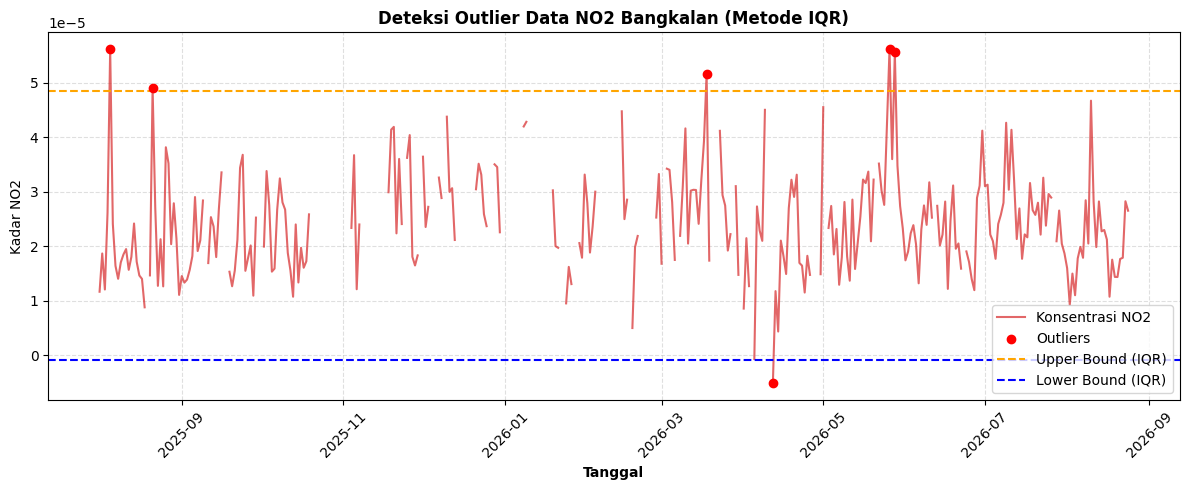

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Baca Master Dataset
df = pd.read_csv("Polusi_Bangkalan_Merged.csv")
df['date'] = pd.to_datetime(df['date'])

gas_target = 'NO2'

# 2. Hitung Batas IQR (Abaikan nilai kosong/NaN sementara)
data_bersih = df[gas_target].dropna()
Q1 = data_bersih.quantile(0.25)
Q3 = data_bersih.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"--- Statistik Outlier {gas_target} Bangkalan ---")
print(f"Q1: {Q1:.6e} | Q3: {Q3:.6e} | IQR: {IQR:.6e}")
print(f"Lower Bound: {lower_bound:.6e}")
print(f"Upper Bound: {upper_bound:.6e}")

# 3. Ekstrak Data Outlier
outliers_iqr = df[(df[gas_target] < lower_bound) | (df[gas_target] > upper_bound)]
print(f"\nJumlah Outlier (IQR): {len(outliers_iqr)}")
print(outliers_iqr[['date', gas_target]].head())

# 4. Visualisasi Time Series dengan Sabuk IQR
plt.figure(figsize=(12, 5))
plt.plot(df['date'], df[gas_target], label=f"Konsentrasi {gas_target}", linewidth=1.5, color='tab:red', alpha=0.7)
plt.scatter(outliers_iqr['date'], outliers_iqr[gas_target], color='red', marker='o', label="Outliers", zorder=5)

plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue', linestyle='dashed', label="Lower Bound (IQR)")

plt.title(f"Deteksi Outlier Data {gas_target} Bangkalan (Metode IQR)", fontweight='bold')
plt.xlabel("Tanggal", fontweight='bold')
plt.ylabel(f"Kadar {gas_target}")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
### 5.2 Analisis Outlier Karbon Monoksida (CO)
Pencilan pada gas CO sering kali menjadi indikator kuat adanya kejadian insidental berskala masif, seperti pembakaran lahan terbuka atau penumpukan polusi asap di area permukiman/jalan raya pada tanggal terjadinya *outlier*.

--- Statistik Outlier CO Bangkalan ---
Q1: 2.666483e-02 | Q3: 3.012376e-02 | IQR: 3.458930e-03
Lower Bound: 2.147644e-02
Upper Bound: 3.531216e-02

Jumlah Outlier (IQR): 8
         date        CO
55 2025-09-24  0.036479
58 2025-09-27  0.035756
68 2025-10-07  0.044806
69 2025-10-08  0.037217
71 2025-10-10  0.035408


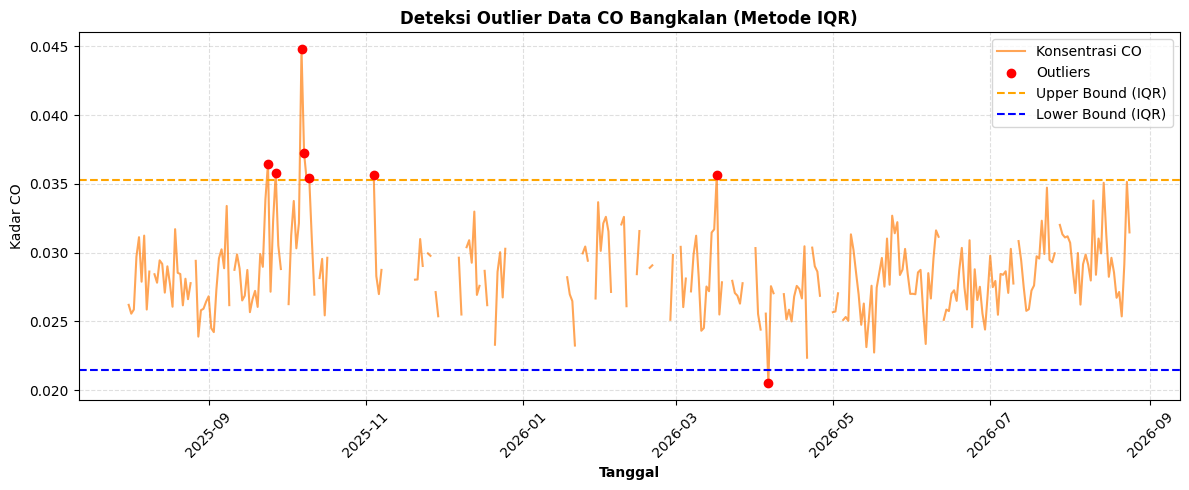

In [17]:
gas_target = 'CO'

data_bersih = df[gas_target].dropna()
Q1 = data_bersih.quantile(0.25)
Q3 = data_bersih.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"--- Statistik Outlier {gas_target} Bangkalan ---")
print(f"Q1: {Q1:.6e} | Q3: {Q3:.6e} | IQR: {IQR:.6e}")
print(f"Lower Bound: {lower_bound:.6e}")
print(f"Upper Bound: {upper_bound:.6e}")

outliers_iqr = df[(df[gas_target] < lower_bound) | (df[gas_target] > upper_bound)]
print(f"\nJumlah Outlier (IQR): {len(outliers_iqr)}")
print(outliers_iqr[['date', gas_target]].head())

plt.figure(figsize=(12, 5))
plt.plot(df['date'], df[gas_target], label=f"Konsentrasi {gas_target}", linewidth=1.5, color='tab:orange', alpha=0.7)
plt.scatter(outliers_iqr['date'], outliers_iqr[gas_target], color='red', marker='o', label="Outliers", zorder=5)

plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue', linestyle='dashed', label="Lower Bound (IQR)")

plt.title(f"Deteksi Outlier Data {gas_target} Bangkalan (Metode IQR)", fontweight='bold')
plt.xlabel("Tanggal", fontweight='bold')
plt.ylabel(f"Kadar {gas_target}")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
### 5.3 Analisis Outlier Ozon Permukaan (O₃)
Sebagai polutan sekunder, kemunculan *outlier* Ozon Permukaan (O₃) sangat bergantung pada intensitas sinar matahari. Titik-titik ekstrem yang menembus batas kewajaran IQR menunjukkan adanya cuaca panas ekstrem atau reaksi fotokimia masif di langit Madura.

--- Statistik Outlier O3 Bangkalan ---
Q1: 1.140442e-01 | Q3: 1.171546e-01 | IQR: 3.110307e-03
Lower Bound: 1.093788e-01
Upper Bound: 1.218200e-01

Jumlah Outlier (IQR): 2
          date        O3
374 2026-08-09  0.122673
375 2026-08-10  0.122118


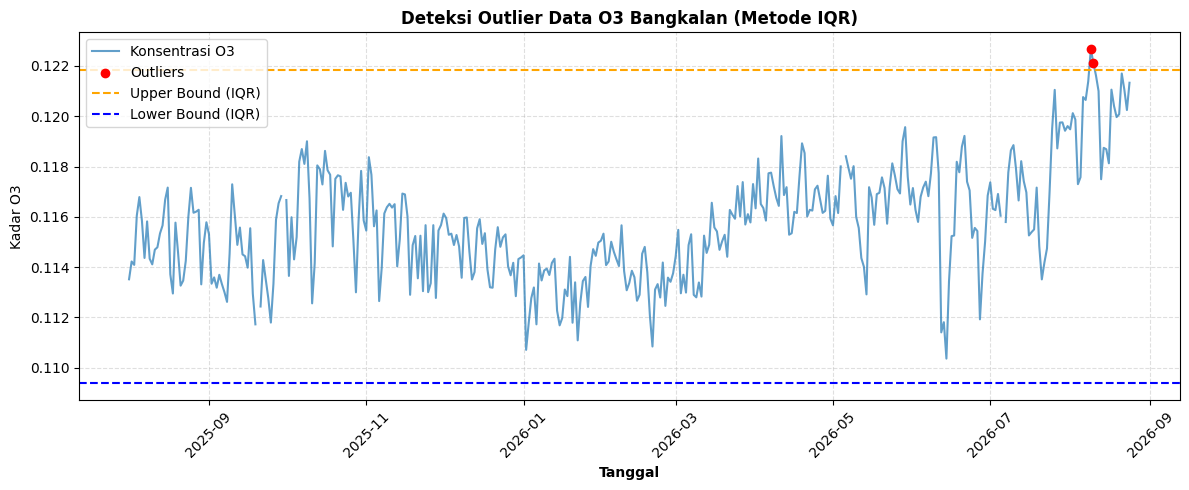

In [18]:
gas_target = 'O3'

data_bersih = df[gas_target].dropna()
Q1 = data_bersih.quantile(0.25)
Q3 = data_bersih.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"--- Statistik Outlier {gas_target} Bangkalan ---")
print(f"Q1: {Q1:.6e} | Q3: {Q3:.6e} | IQR: {IQR:.6e}")
print(f"Lower Bound: {lower_bound:.6e}")
print(f"Upper Bound: {upper_bound:.6e}")

outliers_iqr = df[(df[gas_target] < lower_bound) | (df[gas_target] > upper_bound)]
print(f"Jumlah Outlier (IQR): {len(outliers_iqr)}")
print(outliers_iqr[['date', gas_target]].head())

plt.figure(figsize=(12, 5))
plt.plot(df['date'], df[gas_target], label=f"Konsentrasi {gas_target}", linewidth=1.5, color='tab:blue', alpha=0.7)
plt.scatter(outliers_iqr['date'], outliers_iqr[gas_target], color='red', marker='o', label="Outliers", zorder=5)

plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue', linestyle='dashed', label="Lower Bound (IQR)")

plt.title(f"Deteksi Outlier Data {gas_target} Bangkalan (Metode IQR)", fontweight='bold')
plt.xlabel("Tanggal", fontweight='bold')
plt.ylabel(f"Kadar {gas_target}")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
### 5.4 Analisis Outlier Sulfur Dioksida (SO₂)
Deteksi *outlier* pada gas SO₂ di wilayah Bangkalan umumnya sangat dinamis. Pencilan nilai tinggi sering kali bersumber dari emisi perkapalan di Selat Madura, sementara nilai yang berada di bawah *Lower Bound* (bahkan mencapai area negatif) merepresentasikan keterbatasan alat baca sensor satelit terhadap gas dalam konsentrasi yang terlalu tipis.

--- Statistik Outlier SO2 Bangkalan ---
Q1: -2.204821e-05 | Q3: 1.044044e-04 | IQR: 1.264526e-04
Lower Bound: -2.117271e-04
Upper Bound: 2.940832e-04

Jumlah Outlier (IQR): 18
         date       SO2
6  2025-08-06  0.000427
20 2025-08-20  0.000969
25 2025-08-25  0.000298
41 2025-09-10 -0.000268
74 2025-10-13  0.000840


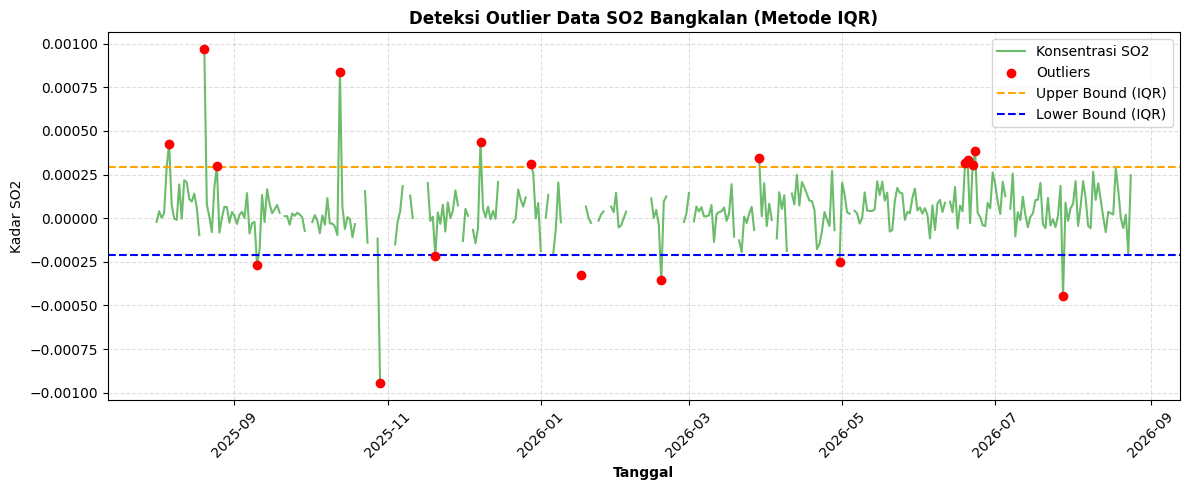

In [19]:
gas_target = 'SO2'

data_bersih = df[gas_target].dropna()
Q1 = data_bersih.quantile(0.25)
Q3 = data_bersih.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"--- Statistik Outlier {gas_target} Bangkalan ---")
print(f"Q1: {Q1:.6e} | Q3: {Q3:.6e} | IQR: {IQR:.6e}")
print(f"Lower Bound: {lower_bound:.6e}")
print(f"Upper Bound: {upper_bound:.6e}")

outliers_iqr = df[(df[gas_target] < lower_bound) | (df[gas_target] > upper_bound)]
print(f"Jumlah Outlier (IQR): {len(outliers_iqr)}")
print(outliers_iqr[['date', gas_target]].head())

plt.figure(figsize=(12, 5))
plt.plot(df['date'], df[gas_target], label=f"Konsentrasi {gas_target}", linewidth=1.5, color='tab:green', alpha=0.7)
plt.scatter(outliers_iqr['date'], outliers_iqr[gas_target], color='red', marker='o', label="Outliers", zorder=5)

plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue', linestyle='dashed', label="Lower Bound (IQR)")

plt.title(f"Deteksi Outlier Data {gas_target} Bangkalan (Metode IQR)", fontweight='bold')
plt.xlabel("Tanggal", fontweight='bold')
plt.ylabel(f"Kadar {gas_target}")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()